In [6]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_ollama import ChatOllama
# import sqlite3
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [7]:
llm = ChatOllama(model="llama3")

MAX_TOKENS = 150


def chat_node(state: MessagesState) -> MessagesState:
    # Applying trimming strategy to keep the most recent messages
    messages = trim_messages(
        state['messages'], 
        strategy="last", 
        token_counter=count_tokens_approximately, 
        max_tokens=MAX_TOKENS
    )
    print("Current Token Count:", count_tokens_approximately(messages=messages))

    # FIX: Use object attributes instead of dictionary subscription
    for message in messages:
        print(f"{message.type}: {message.content}")

    response = llm.invoke(messages)
    return {"messages": [response]}

def delete_old(state: MessagesState) -> MessagesState:
    # This node is responsible for deleting old messages from the state
    messages = state['messages']
    if len(messages) > 10:  # Arbitrary condition to trigger deletion
        to_remove = messages[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}
    return {}

In [8]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_node("delete_old", delete_old)
builder.add_edge(START, "chat")
builder.add_edge("chat", "delete_old")
builder.add_edge("delete_old", END)


# connection = sqlite3.connect("memory.db", check_same_thread=False)
checkpointer = InMemorySaver()
model = builder.compile(checkpointer=checkpointer)

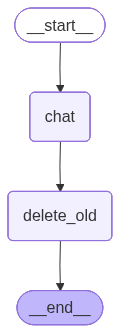

In [9]:
from IPython.display import Image
Image(model.get_graph().draw_mermaid_png())

SUMMARIZATION WITH THE HELP OF DELETION

In [10]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_ollama import ChatOllama
# import sqlite3
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [11]:
llm = ChatOllama(model="llama3")

class ChatState(MessagesState):
    summary: str


MAX_TOKENS = 150


def chat_node(state: ChatState) -> ChatState:
    messages = []
    if state['summary']:
        messages.append({"role" : "system", "content" : f"Summary of previous conversation: {state['summary']}"})
    messages.extend(state['messages'])
    print(messages)
    response = llm.invoke(messages)
    return {"messages": [response]}
    

def summarize_node(state: ChatState) -> ChatState:
    existing_summary = state.get('summary', '')
    if existing_summary:
        prompt = (
            f"Existing summary: {existing_summary}\n"
            "Extend the summary using the conversation above."
        )
    else:
        prompt = "Summarize the conversation above."
    messages_for_summary = state['messages'] + [HumanMessage(content=prompt)]
    summary_response = llm.invoke(messages_for_summary)
    messages_to_delete = state['messages'][:-2]
    return {
        "summary": summary_response.content,
        "messages" : [RemoveMessage(id=m.id) for m in messages_to_delete]
    }

#condition
def should_summarize(state: ChatState) -> bool:
    return len(state['messages']) > 6

In [12]:
checkPointer = InMemorySaver()
builder = StateGraph(ChatState)
builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_node)
builder.add_edge(START, "chat")
builder.add_conditional_edges("chat", should_summarize, {
    "true": "summarize",
    "false": END
})

model1 = builder.compile(checkpointer=checkPointer)

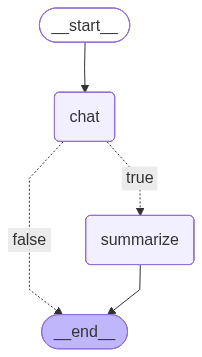

In [13]:
Image(model1.get_graph().draw_mermaid_png())